# Lysbro Platform Analytics

This notebook reads from the reporting database produced by `etl.py` and visualises key business metrics for the Lysbro video conferencing platform. Every chart is also saved to `output/` so the README can embed it.

In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

from config import OUTPUT_DIR, REPORT_DB

TEXT, MUTED, GRID = "#e2e8f0", "#94a3b8", "#1e293b"
BLUE, CYAN, PURPLE, GREEN, AMBER, RED = (
    "#3b82f6",
    "#06b6d4",
    "#a78bfa",
    "#22c55e",
    "#f59e0b",
    "#ef4444",
)

plt.rcParams.update(
    {
        "figure.facecolor": "#05070f",
        "axes.facecolor": "#080b18",
        "axes.edgecolor": GRID,
        "axes.labelcolor": MUTED,
        "xtick.color": "#475569",
        "ytick.color": "#475569",
        "text.color": TEXT,
        "grid.color": GRID,
        "grid.linestyle": "--",
        "axes.axisbelow": True,
        "font.family": "sans-serif",
    }
)

PLAN_COLORS = {"gratis": BLUE, "pro": PURPLE, "erhverv": CYAN}
FALLBACK_COLOR = "#94a3b8"  # any plan the palette does not know
RSVP_COLORS = {"accepted": GREEN, "pending": AMBER, "declined": RED}


def query(sql: str) -> pd.DataFrame:
    with sqlite3.connect(REPORT_DB) as db:
        return pd.read_sql(sql, db)


def finish(ax, title: str, filename: str) -> None:
    """Apply the shared title style, save the figure to output/ and show it."""
    ax.set_title(title, color=TEXT, pad=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


def month_axis(ax, months: pd.Series) -> None:
    ax.set_xticks(range(len(months)))
    ax.set_xticklabels(months, rotation=45, ha="right", fontsize=8)

## 1. Plan distribution

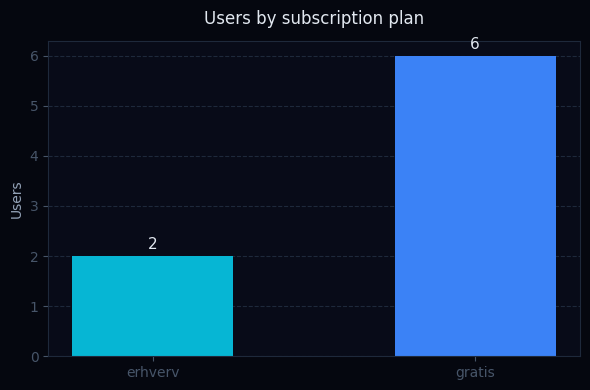

,plan,user_count
0,erhverv,2
1,gratis,6


In [2]:
plans = query("SELECT * FROM plan_distribution")

fig, ax = plt.subplots(figsize=(6, 4))
colors = plans["plan"].map(PLAN_COLORS).fillna(FALLBACK_COLOR)
bars = ax.bar(plans["plan"], plans["user_count"], color=colors, width=0.5)
ax.bar_label(bars, color=TEXT, fontsize=11, padding=3)
ax.set_ylabel("Users")
ax.yaxis.grid(True)
finish(ax, "Users by subscription plan", "plan_distribution.png")
plans

## 2. Monthly signups

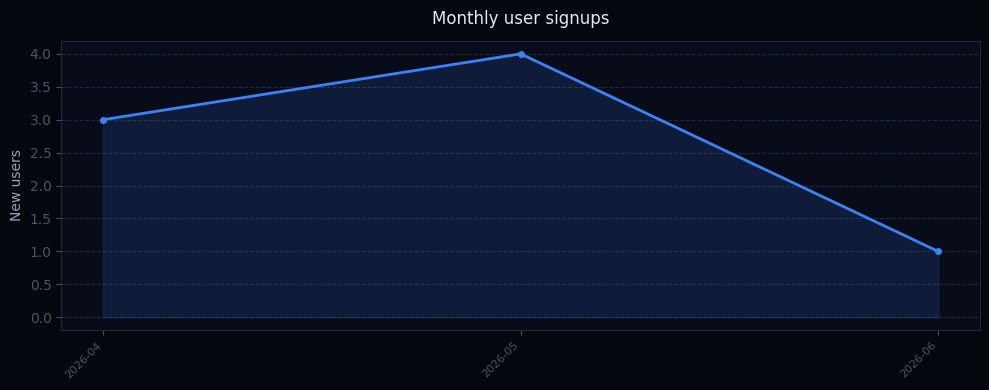

In [3]:
signups = query("SELECT * FROM monthly_signups")
x = range(len(signups))

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x, signups["signups"], alpha=0.15, color=BLUE)
ax.plot(x, signups["signups"], color=BLUE, linewidth=2, marker="o", markersize=4)
month_axis(ax, signups["month"])
ax.set_ylabel("New users")
ax.yaxis.grid(True)
finish(ax, "Monthly user signups", "monthly_signups.png")

## 3. Monthly meetings

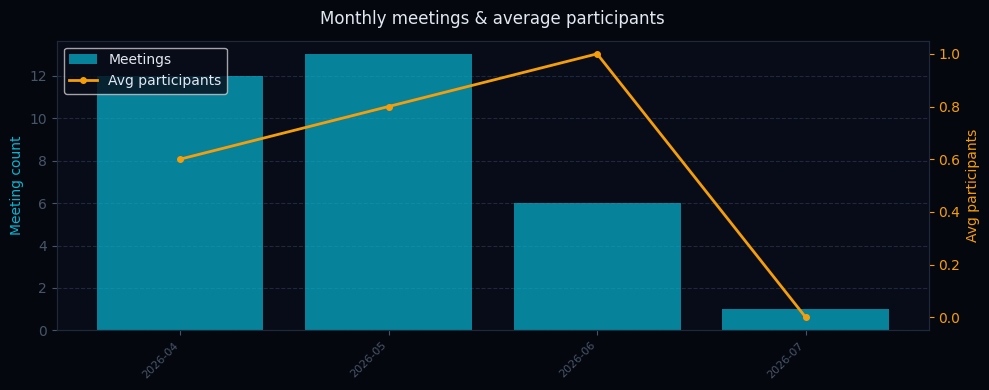

In [4]:
mm = query("SELECT * FROM monthly_meetings")
x = range(len(mm))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(x, mm["meeting_count"], color=CYAN, alpha=0.7, label="Meetings")
ax2.plot(
    x,
    mm["avg_participants"],
    color=AMBER,
    linewidth=2,
    marker="o",
    markersize=4,
    label="Avg participants",
)

month_axis(ax1, mm["month"])
ax1.set_ylabel("Meeting count", color=CYAN)
ax2.set_ylabel("Avg participants", color=AMBER)
ax2.tick_params(colors=AMBER)
ax1.yaxis.grid(True)

handles = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
ax1.legend(handles=handles, loc="upper left")
finish(ax1, "Monthly meetings & average participants", "monthly_meetings.png")

## 4. RSVP acceptance rate

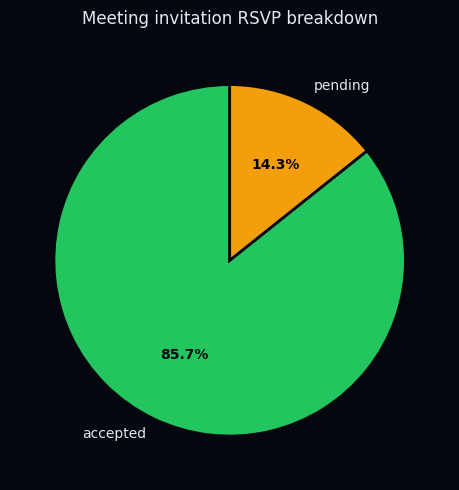

,rsvp,rsvp_count,pct
0,accepted,18,85.7
1,pending,3,14.3


In [5]:
rsvp = query("SELECT * FROM rsvp_summary")

fig, ax = plt.subplots(figsize=(5, 5))
_, _, autotexts = ax.pie(
    rsvp["rsvp_count"],
    labels=rsvp["rsvp"],
    colors=rsvp["rsvp"].map(RSVP_COLORS),
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "#05070f", "linewidth": 2},
)
plt.setp(autotexts, color="#05070f", fontweight="bold")
finish(ax, "Meeting invitation RSVP breakdown", "rsvp_breakdown.png")
rsvp

## 5. Daily message volume (7-day rolling average)

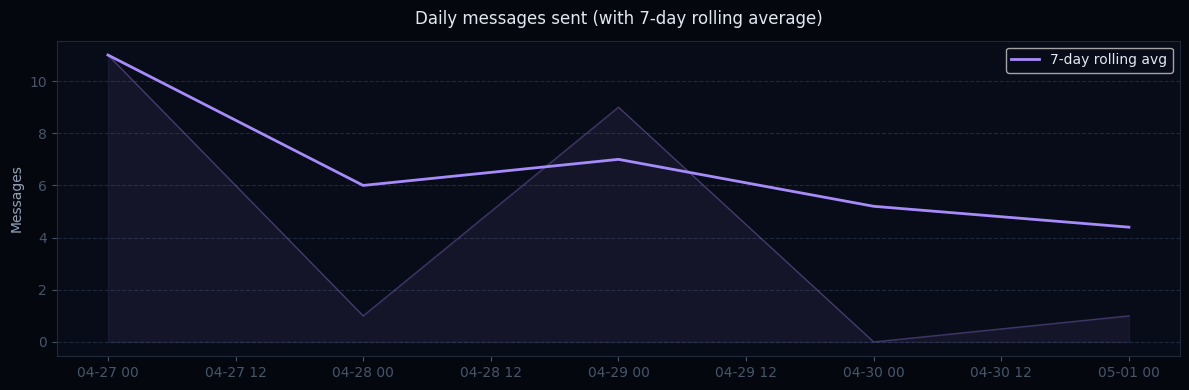

In [6]:
msgs = query("SELECT * FROM daily_messages")
msgs["date"] = pd.to_datetime(msgs["date"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(msgs["date"], msgs["messages_sent"], alpha=0.08, color=PURPLE)
ax.plot(msgs["date"], msgs["messages_sent"], color=PURPLE, alpha=0.3, linewidth=1)
ax.plot(msgs["date"], msgs["rolling_7d"], color=PURPLE, linewidth=2, label="7-day rolling avg")
ax.set_ylabel("Messages")
ax.yaxis.grid(True)
ax.legend()
finish(ax, "Daily messages sent (with 7-day rolling average)", "daily_messages.png")

## 6. Average meetings per user by plan

The `users` column is the sample size behind each average. Only a couple of users are on the *erhverv* plan, so treat that bar as illustrative rather than statistically meaningful.

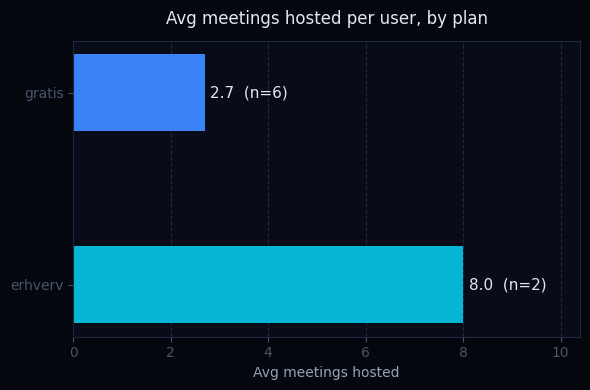

,plan,avg_meetings,users
0,erhverv,8.0,2
1,gratis,2.7,6


In [7]:
mpu = query("SELECT * FROM meetings_per_user_by_plan")

fig, ax = plt.subplots(figsize=(6, 4))
colors = mpu["plan"].map(PLAN_COLORS).fillna(FALLBACK_COLOR)
bars = ax.barh(mpu["plan"], mpu["avg_meetings"], color=colors, height=0.4)
ax.bar_label(
    bars,
    labels=[f"{v}  (n={n})" for v, n in zip(mpu["avg_meetings"], mpu["users"], strict=True)],
    color=TEXT,
    fontsize=11,
    padding=4,
)
ax.set_xlim(0, mpu["avg_meetings"].max() * 1.3)
ax.set_xlabel("Avg meetings hosted")
ax.xaxis.grid(True)
finish(ax, "Avg meetings hosted per user, by plan", "meetings_per_user.png")
mpu